# Implement linear regression with one variable on the California Housing Dataset

### Import Packages

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

### Load dataset


In [10]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

### Select one feature

In [11]:
X=data[['AveRooms']].values
y=data['Price'].values

### Split Data

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Feature Scaling

In [14]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

  ### Gradient Descent

In [48]:
w=0
b=0

learning_rate=0.01
epochs=1000
cost_history=[]
n=len(X_train_scaled)
for i in range(epochs):
    
    y_pred=w*X_train_scaled.flatten()+b 
    cost=(1/(2*n))*np.sum((y_pred-y_train)**2)
    cost_history.append(cost)
    
    dw=(1/n)*np.sum((y_pred-y_train)*X_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred-y_train)



   
    w=w-learning_rate*dw
    b=b-learning_rate*db

    if i%100==0:
        
        print(f"Epoch {i},Cost={cost:.4f}")

y_pred_gd=w*X_test_scaled.flatten()+b
    

Epoch 0,Cost=2.8149
Epoch 100,Cost=0.9414
Epoch 200,Cost=0.6904
Epoch 300,Cost=0.6568
Epoch 400,Cost=0.6523
Epoch 500,Cost=0.6517
Epoch 600,Cost=0.6516
Epoch 700,Cost=0.6516
Epoch 800,Cost=0.6516
Epoch 900,Cost=0.6516


In [31]:
print("Gradient Descent")
print("----------------")
print("Weight= ",w)
print("Bias= ",b)
print("MSE= ",mean_squared_error(y_test,y_pred_gd))
print("R2 Score= ",r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight=  0.18323090648660517
Bias=  2.0718574888450205
MSE=  1.292327655590046
R2 Score=  0.013798228607320828


In [32]:
X_train_ne=np.c_[np.ones((len(X_train),1)),X_train] 
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test] 
theta=np.linalg.inv(X_train_ne.T @X_train_ne)@X_train_ne.T@y_train
y_pred_ne=X_test_ne @theta

In [33]:
print("Normal Equation")
print("---------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE= ",mean_squared_error(y_test,y_pred_ne))
print("R2 Score= ",r2_score(y_test,y_pred_ne))

Normal Equation
---------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE=  1.2923314440807299
R2 Score=  0.013795337532284901


### cost convergence curve

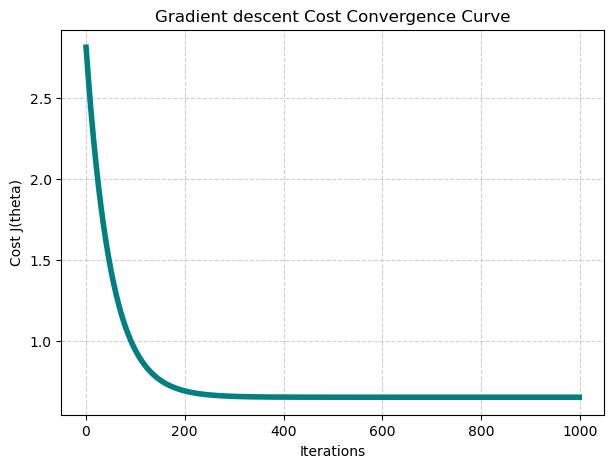

In [47]:
plt.figure(figsize=(7,5))
plt.plot(cost_history,color='teal',linewidth=4)
plt.title("Gradient descent Cost Convergence Curve")
plt.xlabel("Iterations")
plt.ylabel("Cost J(theta)")
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

### Regression Line Visualization

In [49]:
#Sort x values for a smooth line

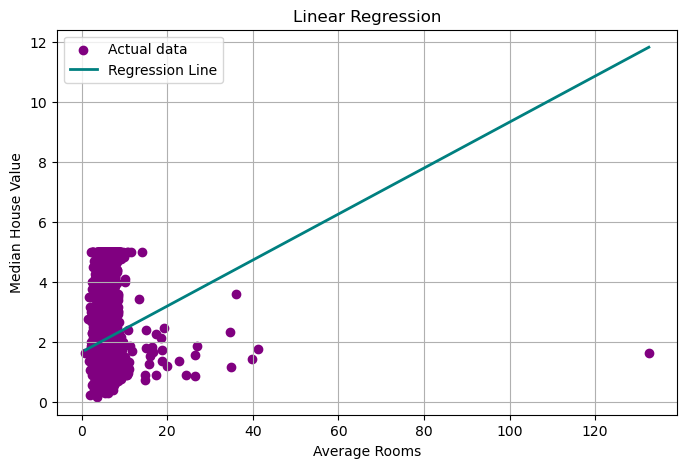

In [62]:
index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color='purple',label="Actual data")
plt.plot(X_test.flatten()[index], y_pred_ne[index],color='teal', linewidth=2,label="Regression Line")
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

#step 1
w=0
b=0
#---------
learning_rate=0.01
epochs=1000
n=len(X_train_scaled)
for i in range(epochs):
    # step 2
    y_pred=w*X_train_scaled.flatten()+b #  2D array->1D array for w and X_train_scaled
    #--------

    
    #step 3
    dw=(1/n)*np.sum((y_pred-y_train)*X_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred-y_train)
    #------


    #step 4
    w=w-learning_rate*dw
    b=b-learning_rate*db
    #------
    
    if i%100==0:
        cost=(1/(2*n))*np.sum((y_pred-y_train)**2)
        print(f"Epoch {i},Cost={cost:.4f}")

y_pred_gd=w*X_test_scaled.flatten()+b